In [29]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Drop Unnamed column if exists
X_train = X_train.loc[:, ~X_train.columns.str.startswith('Unnamed')]
X_test  = X_test.loc[:, ~X_test.columns.str.startswith('Unnamed')]

print("✅ Train:", X_train.shape, "| Test:", X_test.shape)
print("Columns:", X_train.columns.tolist())

✅ Train: (240122, 29) | Test: (60031, 29)
Columns: ['stops', 'class', 'duration', 'days_left', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara', 'source_city_Chennai', 'source_city_Delhi', 'source_city_Hyderabad', 'source_city_Kolkata', 'source_city_Mumbai', 'destination_city_Chennai', 'destination_city_Delhi', 'destination_city_Hyderabad', 'destination_city_Kolkata', 'destination_city_Mumbai', 'departure_time_Early_Morning', 'departure_time_Evening', 'departure_time_Late_Night', 'departure_time_Morning', 'departure_time_Night', 'arrival_time_Early_Morning', 'arrival_time_Evening', 'arrival_time_Late_Night', 'arrival_time_Morning', 'arrival_time_Night']


In [30]:
def evaluate_model(name, y_true, y_pred):
    y_true_actual = np.expm1(y_true)
    y_pred_actual = np.expm1(y_pred)

    mae  = mean_absolute_error(y_true_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    r2   = r2_score(y_true_actual, y_pred_actual)

    print(f"\n── {name} ──────────────────────")
    print(f"  MAE  : ₹{mae:,.0f}")
    print(f"  RMSE : ₹{rmse:,.0f}")
    print(f"  R²   : {r2:.4f}")

    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}


In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
result_lr = evaluate_model("Linear Regression", y_test, y_pred_lr)


── Linear Regression ──────────────────────
  MAE  : ₹4,622
  RMSE : ₹7,917
  R²   : 0.8784


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
result_rf = evaluate_model("Random Forest", y_test, y_pred_rf)


── Random Forest ──────────────────────
  MAE  : ₹1,760
  RMSE : ₹3,474
  R²   : 0.9766


In [33]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50)

y_pred_xgb = xgb.predict(X_test)
result_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb)

[0]	validation_0-rmse:1.01474
[50]	validation_0-rmse:0.21140
[100]	validation_0-rmse:0.19522
[150]	validation_0-rmse:0.18582
[199]	validation_0-rmse:0.17885

── XGBoost ──────────────────────
  MAE  : ₹2,005
  RMSE : ₹3,686
  R²   : 0.9736



                Model          MAE         RMSE        R2
0  Linear Regression  4622.088063  7917.228035  0.878400
1      Random Forest  1759.558260  3473.520526  0.976594
2            XGBoost  2004.992778  3685.560437  0.973649


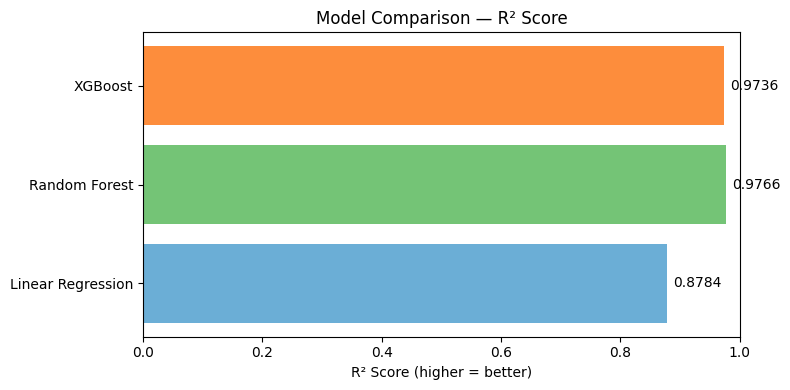

In [34]:
import matplotlib.pyplot as plt

results = pd.DataFrame([result_lr, result_rf, result_xgb])
print("\n", results)

plt.figure(figsize=(8, 4))
plt.barh(results['Model'], results['R2'], color=['#6baed6','#74c476','#fd8d3c'])
plt.xlabel('R² Score (higher = better)')
plt.title('Model Comparison — R² Score')
plt.xlim(0, 1)
for i, v in enumerate(results['R2']):
    plt.text(v + 0.01, i, f"{v:.4f}", va='center')
plt.tight_layout()
plt.show()

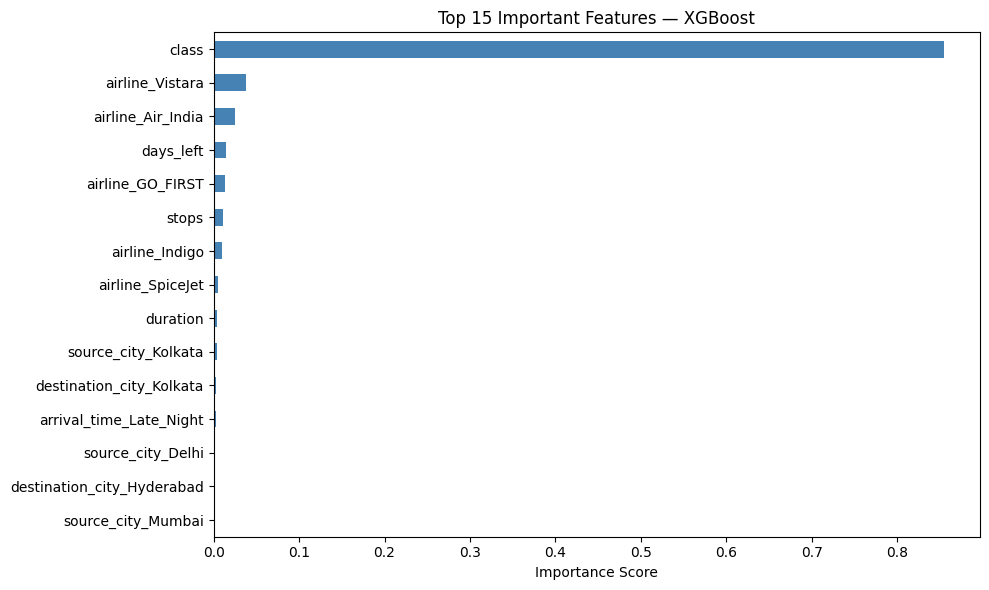

In [35]:
feat_imp     = pd.Series(xgb.feature_importances_, index=X_train.columns)
top_features = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.title('Top 15 Important Features — XGBoost')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

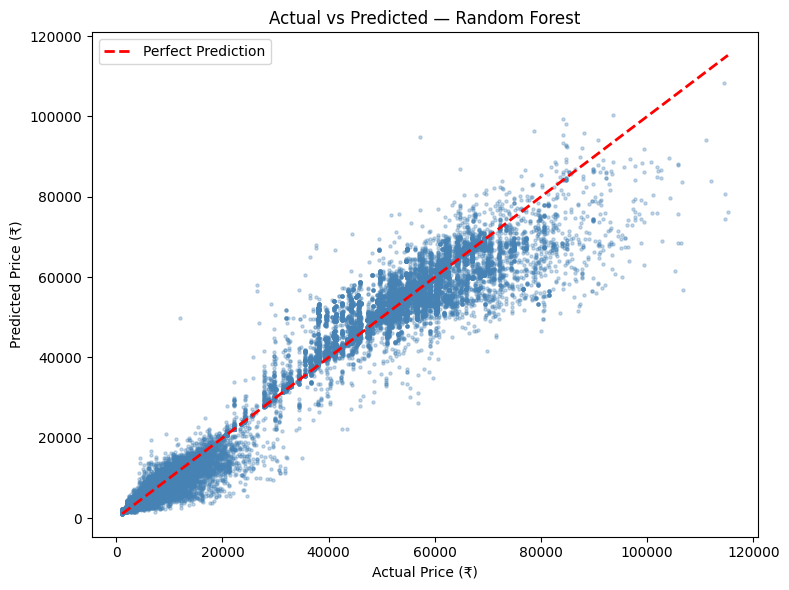

In [36]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_rf)   # using RF since it won

plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.3, color='steelblue', s=5)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title('Actual vs Predicted — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
import joblib, os

os.makedirs('../src', exist_ok=True)
joblib.dump(rf, '../src/flight_price_model_tuned.pkl')
print("Model saved!")

Model saved!


In [38]:
print(X_train.columns.tolist())

['stops', 'class', 'duration', 'days_left', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara', 'source_city_Chennai', 'source_city_Delhi', 'source_city_Hyderabad', 'source_city_Kolkata', 'source_city_Mumbai', 'destination_city_Chennai', 'destination_city_Delhi', 'destination_city_Hyderabad', 'destination_city_Kolkata', 'destination_city_Mumbai', 'departure_time_Early_Morning', 'departure_time_Evening', 'departure_time_Late_Night', 'departure_time_Morning', 'departure_time_Night', 'arrival_time_Early_Morning', 'arrival_time_Evening', 'arrival_time_Late_Night', 'arrival_time_Morning', 'arrival_time_Night']
